In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [8]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cpu')

In [15]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_07.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_07.pt
Last epoch: 1000
Loss history length: 1000


C:\Users\ps302\AppData\Local\Temp\ipykernel_3356\2420416160.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

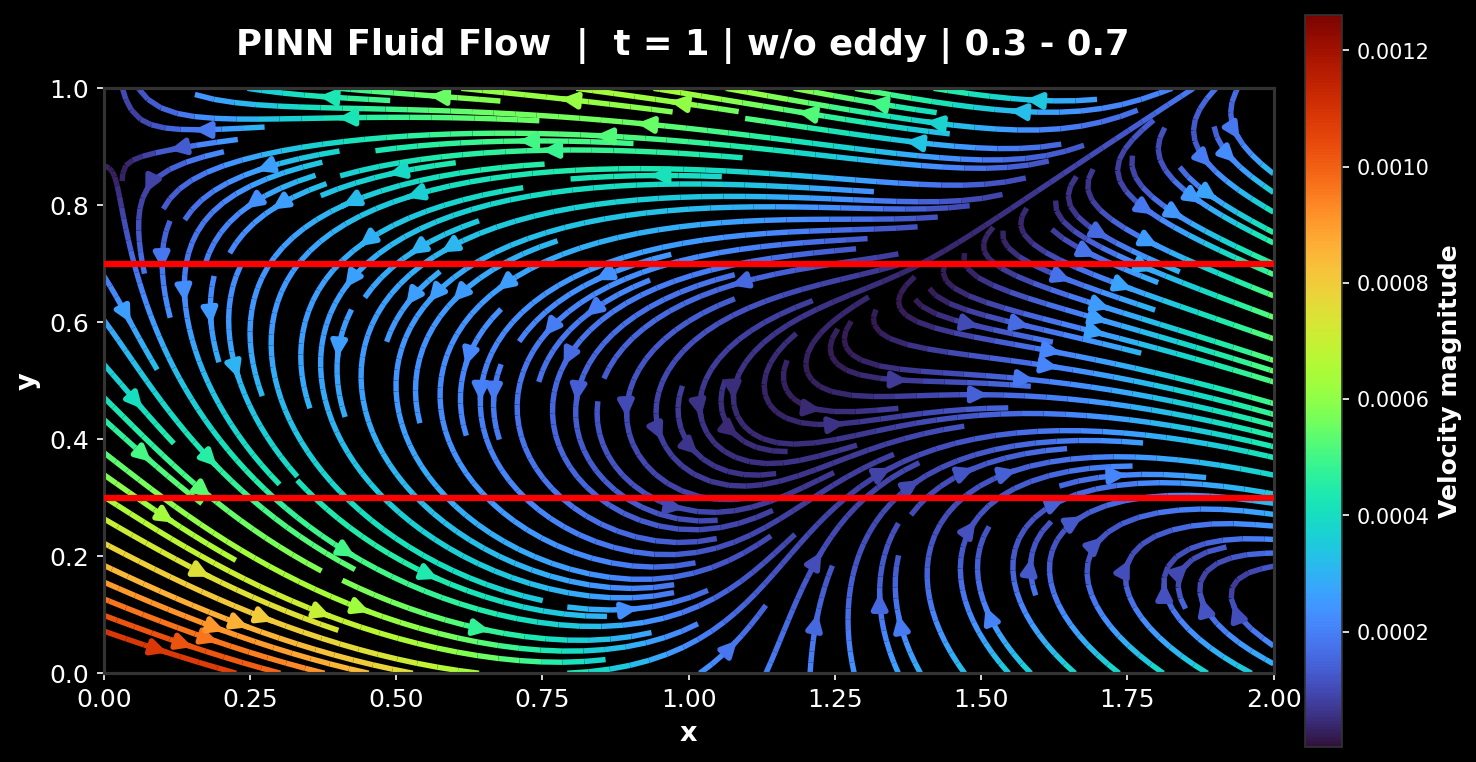

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.3 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000030 m²/s
t = 0.25, |Q| = 0.000068 m²/s
t = 0.50, |Q| = 0.000118 m²/s
t = 0.75, |Q| = 0.000126 m²/s
t = 0.10, |Q| = 0.000015 m²/s


### y-> 0.30 - 0.80


In [23]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.80


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_08_up.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_08_up.pt
Last epoch: 1000
Loss history length: 1000
y = 0.300 m | u = 0.00033 m/s | v = -0.00006 m/s | p = -2943.01096 Pa
y = 0.350 m | u = 0.00040 m/s | v = -0.00009 m/s | p = -3434.49274 Pa
y = 0.400 m | u = 0.00045 m/s | v = -0.00012 m/s | p = -3925.97454 Pa
y = 0.450 m | u = 0.00049 m/s | v = -0.00014 m/s | p = -4417.45636 Pa
y = 0.500 m | u = 0.00052 m/s | v = -0.00016 m/s | p = -4908.93821 Pa
y = 0.551 m | u = 0.00053 m/s | v = -0.00018 m/s | p = -5400.42009 Pa
y = 0.601 m | u = 0.00053 m/s | v = -0.00019 m/s | p = -5891.90198 Pa
y = 0.651 m | u = 0.00052 m/s | v = -0.00021 m/s | p = -6383.38391 Pa
y = 0.701 m | u = 0.00049 m/s | v = -0.00021 m/s | p = -6874.86586 Pa
y = 0.751 m | u = 0.00045 m/s | v = -0.00022 m/s | p = -7366.34784 Pa


C:\Users\ps302\AppData\Local\Temp\ipykernel_3356\107881394.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

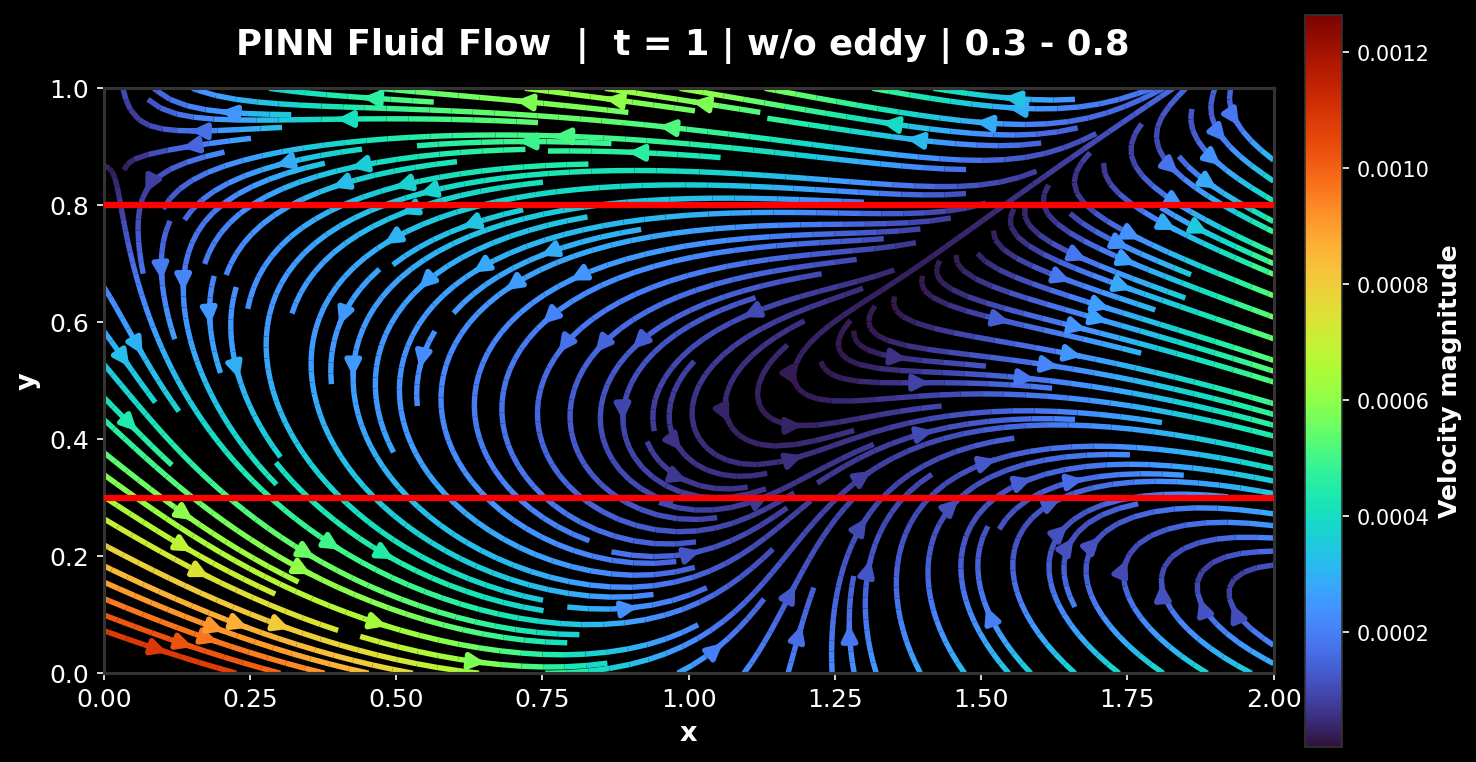

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.3 - 0.8 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.8]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )


ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000028 m²/s
t = 0.25, |Q| = 0.000067 m²/s
t = 0.50, |Q| = 0.000115 m²/s
t = 0.75, |Q| = 0.000123 m²/s
t = 0.10, |Q| = 0.000016 m²/s


### y-> 0.30 - 0.90

In [155]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.90


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_09.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_03_09.pt
Last epoch: 1000
Loss history length: 1000
y = 0.300 m | u = 0.00032 m/s | v = -0.00007 m/s | p = -2943.01308 Pa
y = 0.360 m | u = 0.00040 m/s | v = -0.00010 m/s | p = -3532.79121 Pa
y = 0.420 m | u = 0.00046 m/s | v = -0.00013 m/s | p = -4122.56936 Pa
y = 0.480 m | u = 0.00050 m/s | v = -0.00016 m/s | p = -4712.34754 Pa
y = 0.540 m | u = 0.00053 m/s | v = -0.00018 m/s | p = -5302.12576 Pa
y = 0.601 m | u = 0.00053 m/s | v = -0.00020 m/s | p = -5891.90401 Pa
y = 0.661 m | u = 0.00052 m/s | v = -0.00021 m/s | p = -6481.68229 Pa
y = 0.721 m | u = 0.00049 m/s | v = -0.00022 m/s | p = -7071.46061 Pa
y = 0.781 m | u = 0.00044 m/s | v = -0.00023 m/s | p = -7661.23897 Pa
y = 0.841 m | u = 0.00037 m/s | v = -0.00022 m/s | p = -8251.01736 Pa


C:\Users\ps302\AppData\Local\Temp\ipykernel_3224\3499677545.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

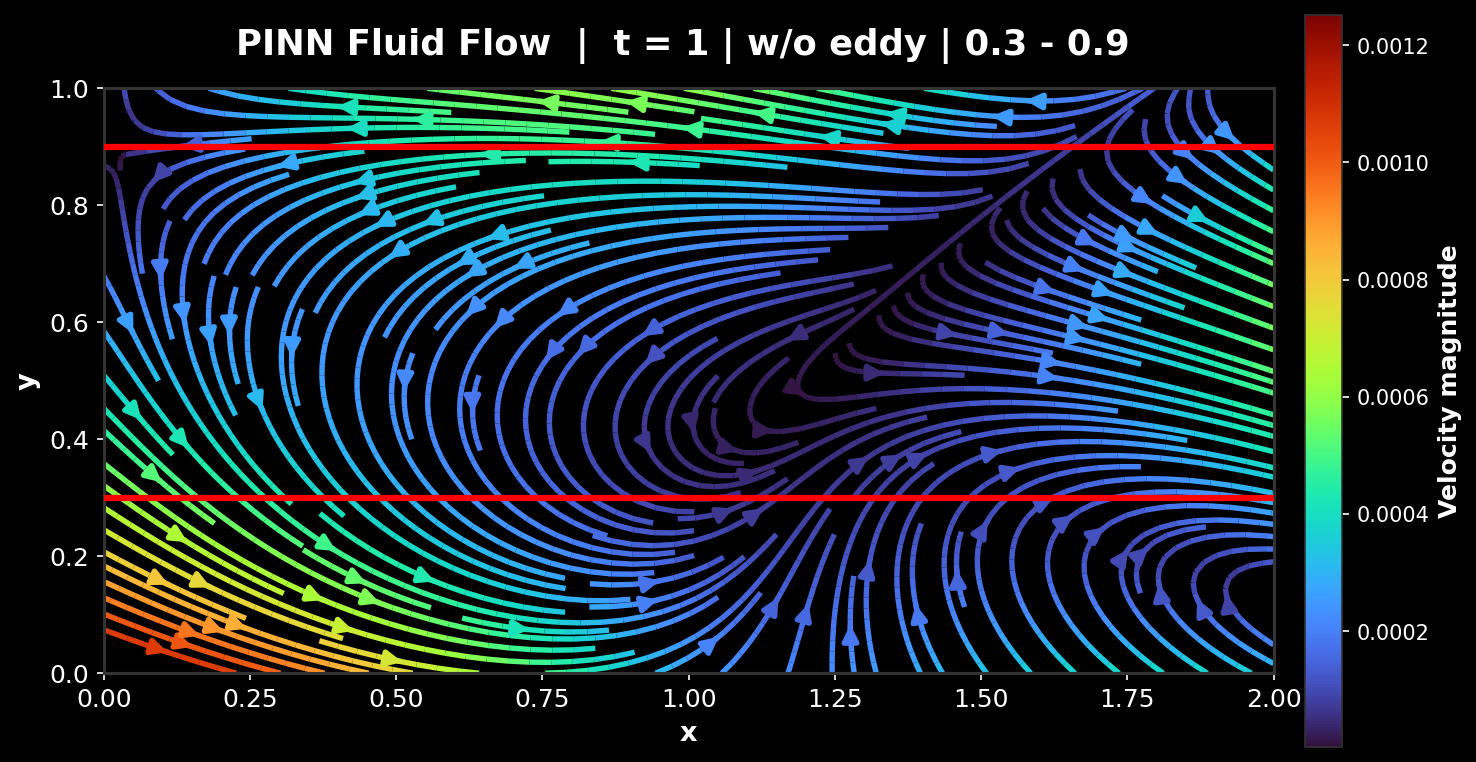

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.3 - 0.9 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.9]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [157]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000025 m²/s
t = 0.25, |Q| = 0.000067 m²/s
t = 0.50, |Q| = 0.000115 m²/s
t = 0.75, |Q| = 0.000123 m²/s
t = 0.10, |Q| = 0.000018 m²/s


### 0.1 - 0.7

In [161]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.10
opening_y_max = 0.70


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_01_07.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_01_07.pt
Last epoch: 1000
Loss history length: 1000


C:\Users\ps302\AppData\Local\Temp\ipykernel_3224\3208800054.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

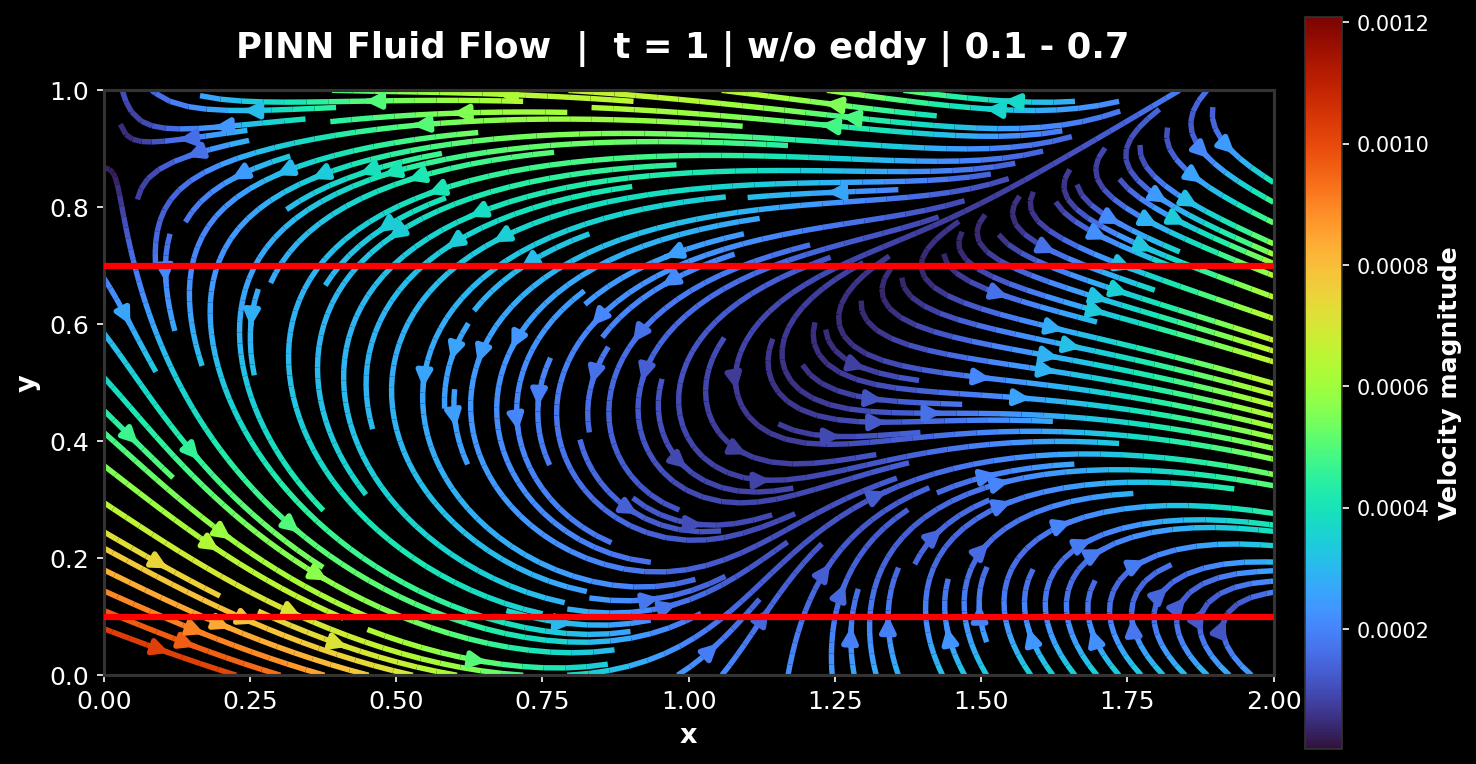

In [162]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.1 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.1, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [163]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000033 m²/s
t = 0.25, |Q| = 0.000066 m²/s
t = 0.50, |Q| = 0.000117 m²/s
t = 0.75, |Q| = 0.000125 m²/s
t = 0.10, |Q| = 0.000013 m²/s


### y-> 0.20 - 0.70


In [164]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.20
opening_y_max = 0.70


import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_02_07.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
# X_open.shape

with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model03_02_07.pt
Last epoch: 1000
Loss history length: 1000
y = 0.200 m | u = 0.00024 m/s | v = -0.00000 m/s | p = -1962.01067 Pa
y = 0.250 m | u = 0.00033 m/s | v = -0.00004 m/s | p = -2453.49248 Pa
y = 0.300 m | u = 0.00041 m/s | v = -0.00007 m/s | p = -2944.97431 Pa
y = 0.350 m | u = 0.00047 m/s | v = -0.00010 m/s | p = -3436.45616 Pa
y = 0.400 m | u = 0.00052 m/s | v = -0.00013 m/s | p = -3927.93803 Pa
y = 0.451 m | u = 0.00056 m/s | v = -0.00015 m/s | p = -4419.41993 Pa
y = 0.501 m | u = 0.00058 m/s | v = -0.00017 m/s | p = -4910.90186 Pa
y = 0.551 m | u = 0.00059 m/s | v = -0.00019 m/s | p = -5402.38381 Pa
y = 0.601 m | u = 0.00058 m/s | v = -0.00020 m/s | p = -5893.86579 Pa
y = 0.651 m | u = 0.00056 m/s | v = -0.00021 m/s | p = -6385.34780 Pa


C:\Users\ps302\AppData\Local\Temp\ipykernel_3224\3213165303.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

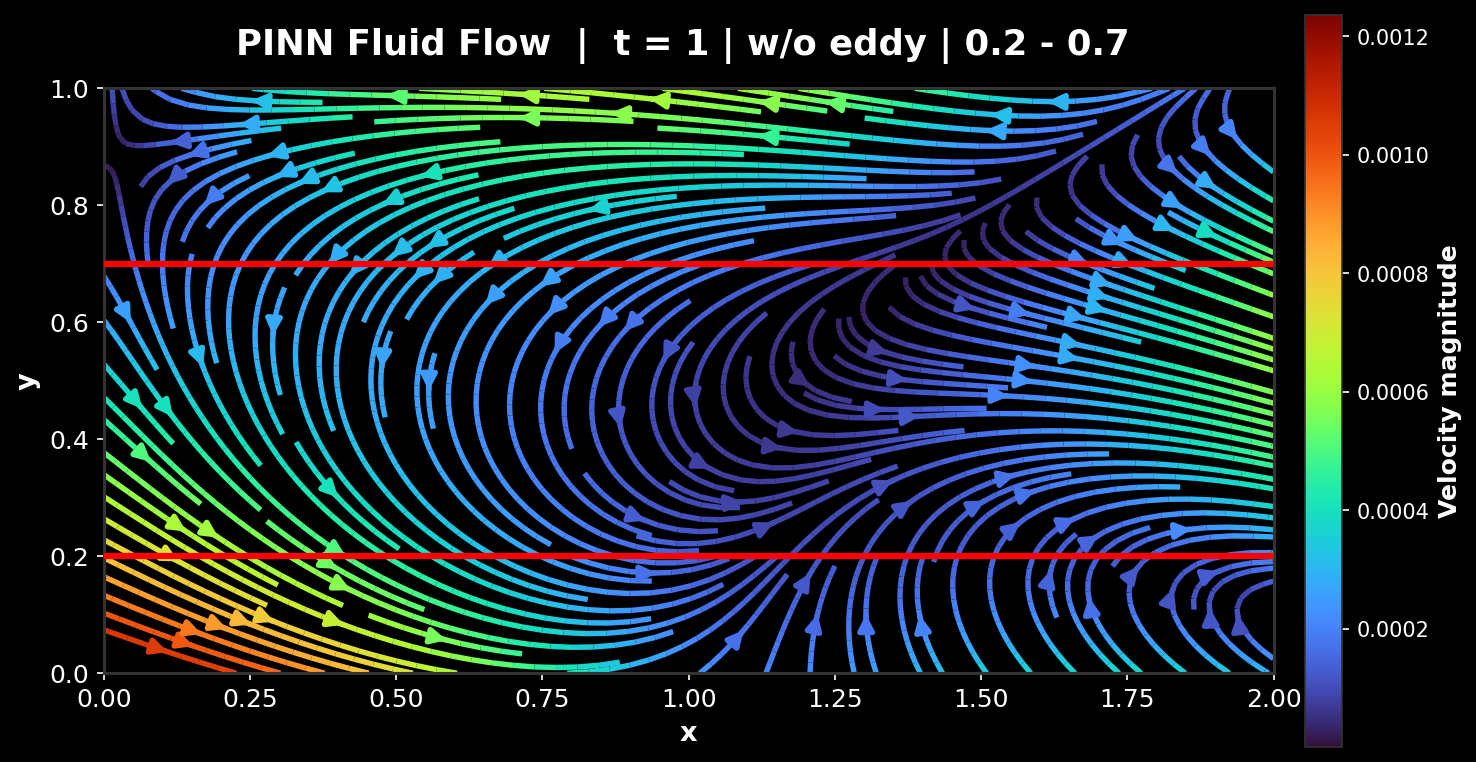

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.2 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.2, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [166]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000032 m²/s
t = 0.25, |Q| = 0.000065 m²/s
t = 0.50, |Q| = 0.000115 m²/s
t = 0.75, |Q| = 0.000122 m²/s
t = 0.10, |Q| = 0.000012 m²/s
